In [1]:
from datamodel import TradingState, Listing, OrderDepth, Observation, Symbol, Trade, Position, Order
from backtester import Backtester
from typing import Dict, List
from trader import Trader
import matplotlib.pyplot as plt
from visualizer import BacktestingResult
import numpy as np
import json

In [2]:
from data_parser import clean_df, get_group_prices
import pandas as pd
import matplotlib.pyplot as plt
from research_tools import get_synthetic_basket_prices
df=get_group_prices(["./data/round_2_data/prices_round_2_day_-1.csv", "./data/round_2_data/prices_round_2_day_0.csv"])

In [3]:
df.head()

,index,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,0,-1,0,CROISSANTS,4304,112,0,0,0,0,4305,112,0,0,0,0,4304.5,0.0
1,1,-1,0,JAMS,6670,66,6669,137,0,0,6671,66,6672,137,0,0,6670.5,0.0
2,2,-1,0,SQUID_INK,2005,1,2002,31,0,0,2006,31,0,0,0,0,2005.5,0.0
3,3,-1,0,PICNIC_BASKET1,59284,20,59283,18,0,0,59294,2,59295,36,0,0,59289.0,0.0
4,4,-1,0,PICNIC_BASKET2,30606,20,30605,18,0,0,30612,20,30613,18,0,0,30609.0,0.0


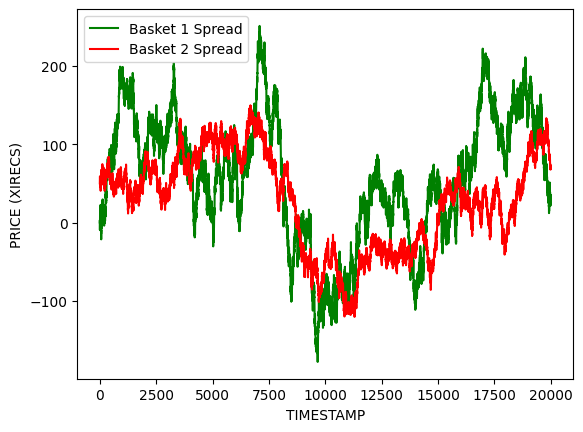

In [11]:
#BASKET RESEARCH

basket_1_price = df.loc[df['product']=="PICNIC_BASKET1"]["mid_price"].to_numpy()
basket_2_price = df.loc[df['product']=="PICNIC_BASKET2"]["mid_price"].to_numpy()

synthetic_basket_1_price = get_synthetic_basket_prices(df, [("CROISSANTS", 6), ("JAMS", 3), ("DJEMBES", 1)])
synthetic_basket_2_price = get_synthetic_basket_prices(df, [("CROISSANTS", 4), ("JAMS", 2)])

plt.plot([i for i in range(len(basket_1_price))], basket_1_price - synthetic_basket_1_price, color="green", label="Basket 1 Spread")
plt.plot([i for i in range(len(basket_2_price))], basket_2_price - synthetic_basket_2_price, color="red", label="Basket 2 Spread")
plt.legend()
plt.xlabel("TIMESTAMP")
plt.ylabel("PRICE (XIRECS)")
plt.show()

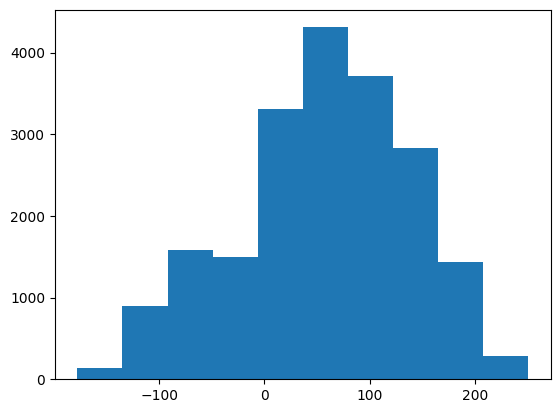

In [12]:
# Get the spread of baskets
plt.hist(basket_1_price - synthetic_basket_1_price, bins=10)
plt.show()

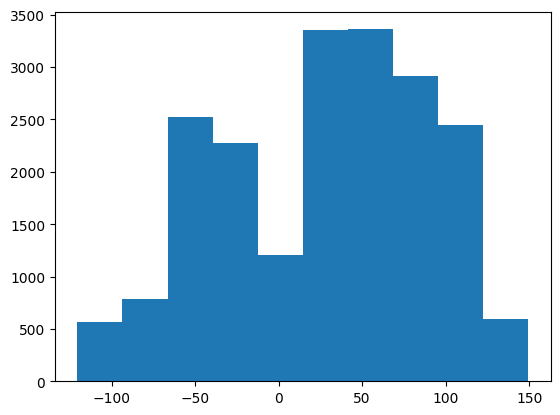

In [13]:
# Get the spread of baskets
plt.hist(basket_2_price - synthetic_basket_2_price, bins=10)
plt.show()

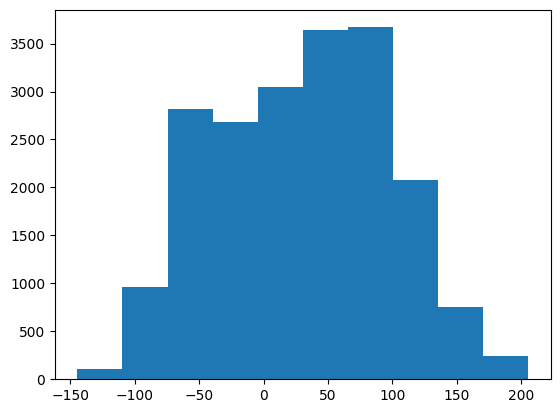

In [16]:
plt.hist((basket_1_price - synthetic_basket_1_price) - (basket_2_price - synthetic_basket_2_price), bins=10)
plt.show()

In [6]:
# Mean and STD of both spreads
print ("MEAN OF BASKET 1 SPREAD " + str((basket_1_price-synthetic_basket_1_price).mean()))
print ("STD OF BASKET 1 SPREAD " + str((basket_1_price-synthetic_basket_1_price).std()))

print ("MEAN OF BASKET 2 SPREAD " + str((basket_2_price-synthetic_basket_2_price).mean()))
print ("STD OF BASKET 2 SPREAD " + str((basket_2_price-synthetic_basket_2_price).std()))

MEAN OF BASKET 1 SPREAD 56.98375
STD OF BASKET 1 SPREAD 81.78642818914089
MEAN OF BASKET 2 SPREAD 27.120475
STD OF BASKET 2 SPREAD 61.83330816214167


In [ ]:
from typing import List
import string
import numpy as np
import json
from typing import Any
import math

from datamodel import *
from datamodel import Listing, Observation, Order, OrderDepth, Symbol, Trade, TradingState


class UserTrader(Trader):
    def __init__(self):
        self.all_symbols = [
            "PICNIC_BASKET1", "PICNIC_BASKET2", "CROISSANTS", "JAMS", "DJEMBES", "KELP", "SQUID_INK", "RAINFOREST_RESIN"
        ]
        self.all_baskets = [
            "PICNIC_BASKET1", "PICNIC_BASKET2"
        ]
        self.baskets_def = {
            "PICNIC_BASKET1": [("CROISSANTS", 6), ("JAMS", 3), ("DJEMBES", 1)],
            "PICNIC_BASKET2": [("CROISSANTS", 4), ("JAMS", 2)]
        }
        self.limits = {
            "PICNIC_BASKET1": 80,
            "PICNIC_BASKET2": 80,
            "CROISSANTS": 80,
            "JAMS": 80,
            "DJEMBES": 80,
        }

    # -------------------------
    # PRICE + SPREAD
    # -------------------------

    def compute_mp(self, state: TradingState):
        self.mid_prices = {}
        for item in self.all_symbols:
            best_bid = max(state.order_depths[item].buy_orders)
            best_ask = min(state.order_depths[item].sell_orders)
            self.mid_prices[item] = int((best_bid + best_ask) / 2)

    def get_limit(self, symbol: str):
        return self.limits.get(symbol, 80)

    def get_spreads(self):
        self.spreads = {}
        for basket in self.baskets_def:
            price = 0
            for item, ratio in self.baskets_def[basket]:
                price += self.mid_prices[item] * ratio
            self.spreads[basket] = self.mid_prices[basket] - price

    # -------------------------
    # BEST PRICES
    # -------------------------

    def compute_best_bids(self, state: TradingState):
        self.best_bids = {}
        for symbol in self.all_symbols:
            self.best_bids[symbol] = max(state.order_depths[symbol].buy_orders)

    def compute_best_asks(self, state: TradingState):
        self.best_asks = {}
        for symbol in self.all_symbols:
            self.best_asks[symbol] = min(state.order_depths[symbol].sell_orders)

    # -------------------------
    # CORE FIX: HEDGE SIZING
    # -------------------------

    def get_max_hedge_size_long(self, state, symbol):
        # BUY basket, SELL components

        # basket constraint
        basket_ask = self.best_asks[symbol]
        basket_vol = abs(state.order_depths[symbol].sell_orders[basket_ask])

        max_size = basket_vol

        # component constraints
        for item, ratio in self.baskets_def[symbol]:
            bid = self.best_bids[item]
            vol = abs(state.order_depths[item].buy_orders[bid])

            max_size = min(max_size, vol // ratio)

        # position constraint
        max_size = min(max_size, self.get_limit(symbol) - state.position.get(symbol, 0))

        return max(0, max_size)

    def get_max_hedge_size_short(self, state, symbol):
        # SELL basket, BUY components

        basket_bid = self.best_bids[symbol]
        basket_vol = abs(state.order_depths[symbol].buy_orders[basket_bid])

        max_size = basket_vol

        for item, ratio in self.baskets_def[symbol]:
            ask = self.best_asks[item]
            vol = abs(state.order_depths[item].sell_orders[ask])

            max_size = min(max_size, vol // ratio)

        max_size = min(max_size, self.get_limit(symbol) + state.position.get(symbol, 0))

        return max(0, max_size)

    # -------------------------
    # EXECUTION
    # -------------------------

    def long_etf(self, state: TradingState, symbol: str):
        size = self.get_max_hedge_size_long(state, symbol)

        if size <= 0:
            return

        # hedge: SELL components
        for item, ratio in self.baskets_def[symbol]:
            price = self.best_bids[item]
            self.result[item].append(Order(item, price, -ratio * size))

        # buy basket
        price = self.best_asks[symbol]
        self.result[symbol].append(Order(symbol, price, size))

    def short_etf(self, state: TradingState, symbol: str):
        size = self.get_max_hedge_size_short(state, symbol)

        if size <= 0:
            return

        # hedge: BUY components
        for item, ratio in self.baskets_def[symbol]:
            price = self.best_asks[item]
            self.result[item].append(Order(item, price, ratio * size))

        # sell basket
        price = self.best_bids[symbol]
        self.result[symbol].append(Order(symbol, price, -size))

    # -------------------------
    # STRATEGY
    # -------------------------

    def trade_etfs(self, state: TradingState):
        if self.spreads["PICNIC_BASKET1"] >= 137:
            self.short_etf(state, "PICNIC_BASKET1")

        if self.spreads["PICNIC_BASKET1"] <= -30:
            self.long_etf(state, "PICNIC_BASKET1")

    # -------------------------
    # ENGINE
    # -------------------------

    def setup_result(self):
        self.result = {}
        for symbol in self.all_symbols:
            self.result[symbol] = []

    def run(self, state: TradingState):
        self.setup_result()

        self.compute_best_bids(state)
        self.compute_best_asks(state)
        self.compute_mp(state)
        self.get_spreads()

        self.trade_etfs(state)

        return self.result, 0, ""

In [4]:
backtesting_engine = Backtester(["./data/round_2_data/prices_round_2_day_-1.csv", "./data/round_2_data/prices_round_2_day_0.csv"], ["./data/round_2_data/trades_round_2_day_-1.csv", "./data/round_2_data/trades_round_2_day_0.csv"])

c:\Projects\IMC_PROSPERITY_4\backtesting_engine\data_parser.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace("", 0)
c:\Projects\IMC_PROSPERITY_4\backtesting_engine\data_parser.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["buyer"].replace(0, "", inplace=True)
c:\Project

In [5]:
sample_trader = UserTrader()
#backtesting_engine.custom_shifter["TOMATOES"]=1.5
backtesting_result = backtesting_engine.run_trader(sample_trader, enable_probabilistic_fills=False, enable_market_trades=True)

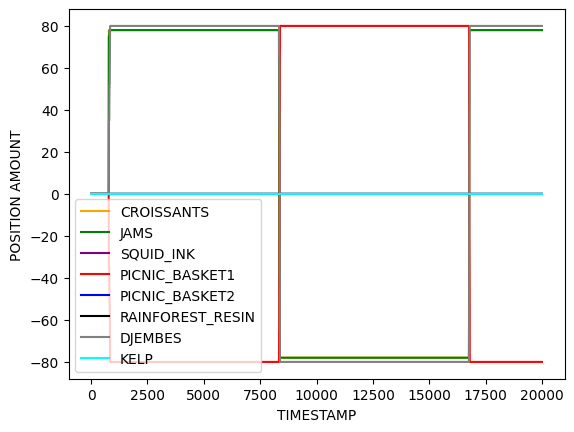

In [6]:
backtesting_result.graph_inventory()

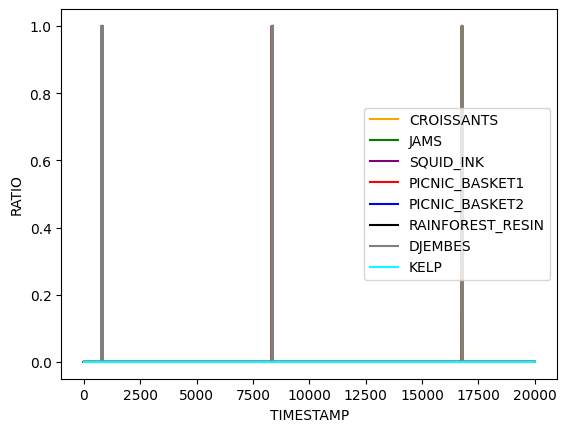

In [7]:
backtesting_result.graph_fill_ratios()

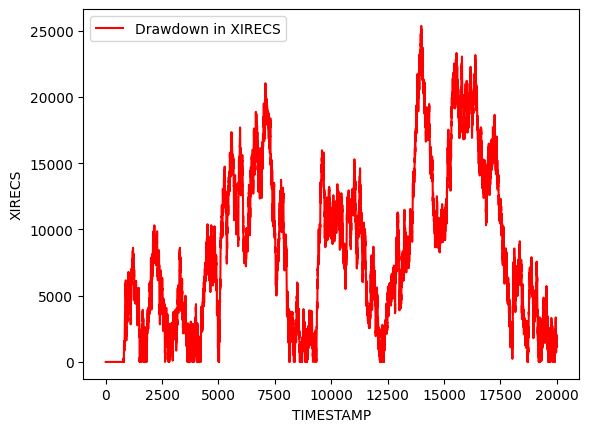

In [8]:
backtesting_result.graph_drawdown()

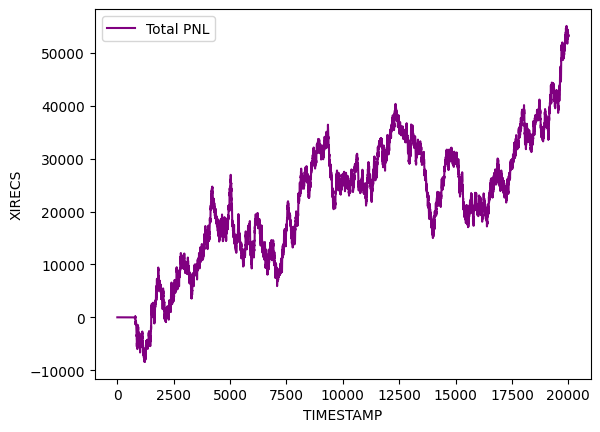

In [9]:
backtesting_result.graph_pnl()

In [60]:
import math

total_runs = 500
all_end_pnl=[]
all_sharpe=[]
for i in range(total_runs):
    backtesting_result = backtesting_engine.run_trader(sample_trader, enable_probabilistic_fills=True)
    t_sum = 0
    total_pnl_series=[]
    for symbol in backtesting_engine.symbols:
        t_sum+=backtesting_result.pnl_realized[len(backtesting_result.pnl_realized)-1][symbol]
        t_sum+=backtesting_result.pnl_unrealized[len(backtesting_result.pnl_realized)-1][symbol]

    for t in range(len(backtesting_result.pnl_realized)):
        s=0
        for symbol in backtesting_engine.symbols:
            s+=backtesting_result.pnl_realized[t][symbol]
            s+=backtesting_result.pnl_unrealized[t][symbol]
        total_pnl_series.append(s)

    returns = np.diff(total_pnl_series)
    mean_ret = returns.mean()
    std_ret = returns.std()
    all_sharpe.append((mean_ret/std_ret)*math.sqrt(len(backtesting_result.pnl_realized)))
    all_end_pnl.append(t_sum)



(array([  5.,   0.,   0.,   0.,   0.,  97., 111., 211.,  37.,  39.]),
 array([ 622. , 1528.6, 2435.2, 3341.8, 4248.4, 5155. , 6061.6, 6968.2,
        7874.8, 8781.4, 9688. ]),
 <BarContainer object of 10 artists>)

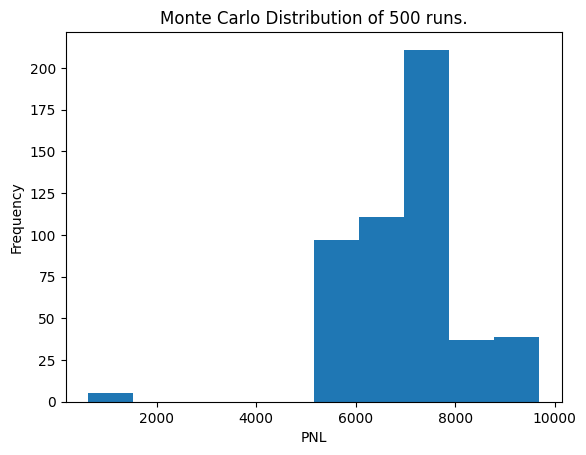

In [61]:
#plt.hist(all_sharpe, bins=10)
plt.title("Monte Carlo Distribution of " + str(total_runs) + " runs.")
plt.xlabel("PNL")
plt.ylabel("Frequency")
plt.hist(all_end_pnl, bins=10)

(array([  5.,   0.,   0.,   0.,  42., 162., 141.,  99.,  19.,  32.]),
 array([0.08036829, 0.23216623, 0.38396417, 0.53576212, 0.68756006,
        0.839358  , 0.99115595, 1.14295389, 1.29475184, 1.44654978,
        1.59834772]),
 <BarContainer object of 10 artists>)

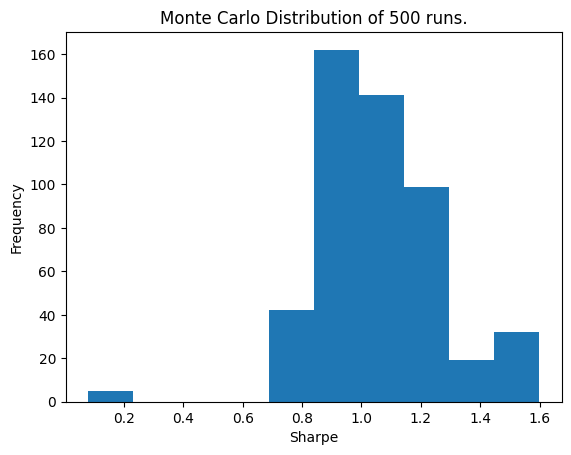

In [62]:
plt.title("Monte Carlo Distribution of " + str(total_runs) + " runs.")
plt.xlabel("Sharpe")
plt.ylabel("Frequency")
plt.hist(all_sharpe, bins=10)

In [63]:
# Print montecarlo sim stats
a_s = np.array(all_sharpe)
print ("Mean Sharpe: " + str(a_s.mean()))
print ("STD Sharpe: " + str(a_s.std()))

standard_error_sharpe = a_s.mean()/math.sqrt(len(all_sharpe))
target_z_score = 1.96

print ("95% Confidence that sharpe is between " + str(a_s.mean() - standard_error_sharpe*target_z_score) + " and " + str(a_s.mean() + standard_error_sharpe*target_z_score))

a_p = np.array(all_end_pnl)
print ("Mean PNL: " + str(a_p.mean()))
print ("STD PNL: " + str(a_p.std()))

standard_error_pnl = a_p.mean()/math.sqrt(len(all_end_pnl))
print ("95% Confidence that PNL is between " + str(a_p.mean() - standard_error_pnl*target_z_score) + " and " + str(a_p.mean() + standard_error_pnl*target_z_score))

Mean Sharpe: 1.0654293556997703
STD Sharpe: 0.2090352682317448
95% Confidence that sharpe is between 0.9720403550886855 and 1.158818356310855
Mean PNL: 6933.282
STD PNL: 1184.0408871639527
95% Confidence that PNL is between 6325.5530375203125 and 7541.010962479688
